In [1]:
import scanpy as sc
adata = sc.read_h5ad('pountain_data/outputs/lb_adata.h5ad')

/home/mmonshiz/micromamba/envs/scvi_env/lib/python3.8/site-packages/setuptools_scm/_integration/setuptools.py:31: RuntimeWarning: 
ERROR: setuptools==59.5.0 is used in combination with setuptools_scm>=8.x

Your build configuration is incomplete and previously worked by accident!
setuptools_scm requires setuptools>=61

Suggested workaround if applicable:
 - migrating from the deprecated setup_requires mechanism to pep517/518
   and using a pyproject.toml to declare build dependencies
   which are reliably pre-installed before running the build tools

  warnings.warn(


In [3]:
import scvi
import anndata
from scvi.model import OperonAwareSCVI
from operon_aware_lib import load_neighbor_indices

# 1. Load and register data
scvi.data.setup_anndata(adata)

# 2. Load neighbor indices (gene name → integer index)
neighbor_indices = load_neighbor_indices("operon_aware_data/operon_neighbors.csv", adata)
# shape: (2, n_pairs), e.g. tensor([[0, 1, 2, ...], [1, 2, 3, ...]])

# 3. Build and train model
model = OperonAwareSCVI(
    adata,
    n_layers=2,
    n_latent=5,
    n_hidden=64,
    dropout_rate=0.1,
    gene_likelihood='zinb',
    dispersion='gene',
    neighbor_indices=neighbor_indices,
    lambda_val=0.05
)
model.train(check_val_every_n_epoch=1,)

# # 4. Get latent representation as usual
# adata.obsm["X_scVI"] = model.get_latent_representation()

INFO     No batch_key inputted, assuming all cells are same batch                                                  
INFO     No label_key inputted, assuming all cells have same label                                                 
INFO     Using data from adata.X                                                                                   
INFO     Computing library size prior per batch                                                                    
INFO     Successfully registered anndata object containing 57627 cells, 3070 vars, 1 batches, 1 labels, and 0      
         proteins. Also registered 0 extra categorical covariates and 0 extra continuous covariates.               
INFO     Please do not further modify adata until model is trained.                                                


GPU available: True, used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


[load_neighbor_indices] Warning: dropping 808 pairs with genes not in adata.var_names
[load_neighbor_indices] Loaded 1323 operon neighbor pairs
Epoch 1/139:   1%|          | 1/139 [00:18<42:01, 18.27s/it, loss=388, v_num=1]

/home/mmonshiz/micromamba/envs/scvi_env/lib/python3.8/site-packages/pytorch_lightning/trainer/callback_hook.py:100: LightningDeprecationWarning: The signature of `Callback.on_train_epoch_end` has changed in v1.3. `outputs` parameter has been removed. Support for the old signature will be removed in v1.5
  warning_cache.deprecation(


Epoch 41/139:  29%|██▉       | 41/139 [12:55<30:49, 18.87s/it, loss=368, v_num=1]

In [ ]:
model.save('pountain_data/outputs/lb_scVI_model_operon_aware')

In [5]:
Z_operon = model.get_latent_representation() 
adata.obsm["X_operon"] = Z_operon
expr_operon = model.get_normalized_expression()  # (n_cells, n_genes)

In [6]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
gff = pd.read_csv("pountain_data/reference/GCF_000005845.2_ASM584v2_genomic.gff",
                 sep="\t", comment='#', names=['chrom', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute'])
chrom_length = gff.loc[0, 'end']

gff['name'] = gff['attribute'].str.replace("^.*;Name=", "", regex=True).str.replace(";.*$", "", regex=True)
gff['locus_tag'] = gff['attribute'].str.replace("^.*;locus_tag=", "", regex=True).str.replace(";.*$", "", regex=True)

gff = gff[gff['feature'] == 'gene'] # Filter for only genes
gff = gff[['chrom', 'start', 'end', 'strand', 'name', 'locus_tag']]
gff.reset_index(inplace=True)

# Set the starting position of each gene (depending on strand)
def set_coord(x):
    if x['strand'] == '+':
        return x['start']
    elif x['strand'] == '-':
        return x['end']
    else:
        raise ValueError('Strand should not be ' + x['strand'])

gff['coord'] = gff.apply(set_coord, axis=1)
gff.index = gff['locus_tag']

# Start of the replication origin - Taken directly from the genbank annotation
origin_start = 3925744
origin_end = 3925975
origin_midpoint = (origin_start + origin_end + 1) / 2 # The +1 gives the origin an integer value
origin_midpoint

# Reset the start coordinate so that the origin is at zero, then sort the GFF by this value
gff = gff.loc[pd.Series(adata.var_names),:]
gff['coord'] = (gff['coord'] - origin_midpoint) % chrom_length
gff = gff.sort_values('coord')

# Filter out extrachromosomal genes (important for genomes with extrachromosomal elements):
gff = gff.loc[gff['chrom'] == 'NC_000913.3']

gff.head()

,index,chrom,start,end,strand,name,locus_tag,coord
locus_tag,,,,,,,,
b3742,8013,NC_000913.3,3926012,3926455,-,mioC,b3742,595.0
b3743,8015,NC_000913.3,3926545,3927003,-,asnC,b3743,1143.0
b3744,8017,NC_000913.3,3927155,3928147,+,asnA,b3744,1295.0
b3745,8019,NC_000913.3,3928152,3929603,-,viaA,b3745,3743.0
b3746,8021,NC_000913.3,3929597,3931093,-,ravA,b3746,5233.0


<AxesSubplot:xlabel='locus_tag', ylabel='locus_tag'>

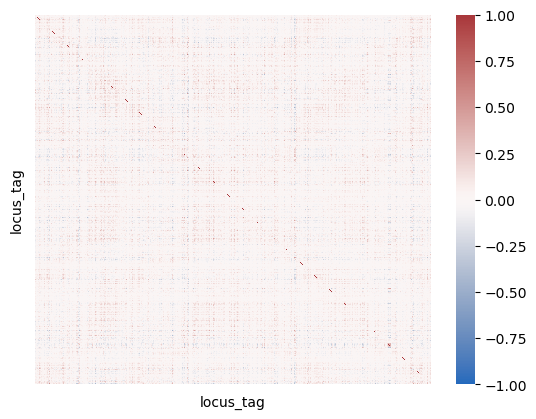

In [8]:
cors = model.get_feature_correlation_matrix(adata)

# Plot (in order of chromosomal location starting from the origin)
sns.heatmap(cors.loc[gff.index, gff.index],
            cmap='vlag', vmin=-1, vmax=1, center=0,
            xticklabels=False, yticklabels=False)

<AxesSubplot:xlabel='locus_tag', ylabel='locus_tag'>

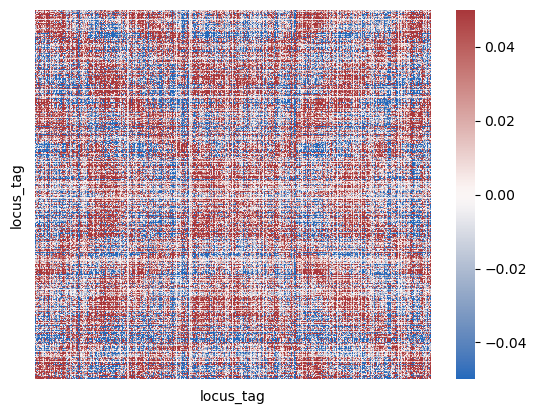

In [9]:
sns.heatmap(cors.loc[gff.index, gff.index],
            cmap='vlag', vmin=-0.05, vmax=0.05, center=0,
            xticklabels=False, yticklabels=False)

In [10]:
from collections import OrderedDict
from scipy.stats import spearmanr


### Function to create bins
# This creates an ordered dictionary where each key is a chromosomal region and each key is a list of genes
# in that bin.
def create_bins(gff, chrom_length, bin_size):
    bins = OrderedDict()
    if type(bin_size) is float:
        bin_size = int(bin_size)
    for bin_start in range(1, chrom_length + 1, bin_size):
        bin_end = bin_start + bin_size - 1
        if bin_end > chrom_length:
            bin_end = chrom_length
        bins[(bin_start, bin_end)] = list(gff.loc[(bin_start <= gff['coord']) & (gff['coord'] <= bin_end), 'locus_tag'])
    return bins

### Function to create binned expression
# This takes the bin dictionary and averages gene expression within each bin.
def bin_expression(counts, bins):
    bin_names = []
    binned_expression = []
    for bin in bins:
        bin_names.append((bin[0] + bin[1]) / 2)
        binned_expression.append(counts.loc[:,np.isin(counts.columns, bins[bin])].mean(axis=1))
    binned_expression_df = pd.DataFrame(binned_expression).transpose()
    binned_expression_df.columns = bin_names
    return binned_expression_df

<AxesSubplot:>

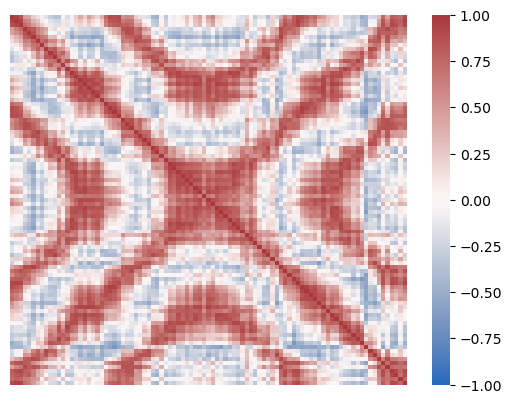

In [12]:
# Get scVI-normalized expression and scale it
normalized_expression = model.get_normalized_expression(adata)
normalized_expression = normalized_expression[gff.index] # Sort by origin-zeroed chromosomal location
log_expression = np.log2(normalized_expression)
scaled_expression = log_expression.apply(lambda x: (x - np.mean(x)) / np.std(x), 0)

# Create bins and use these to bin expression (chrom length taken from the GFF file above)
bins = create_bins(gff, chrom_length, 5e4)
binned_expression = bin_expression(scaled_expression, bins)

bin_cors = spearmanr(binned_expression)[0]
sns.heatmap(bin_cors, center=0, vmin=-1, vmax=1, cmap='vlag', xticklabels=False, yticklabels=False)

Loading data and models...
INFO     No batch_key inputted, assuming all cells are same batch                                                  
INFO     No label_key inputted, assuming all cells have same label                                                 
INFO     Using data from adata.X                                                                                   
INFO     Computing library size prior per batch                                                                    
INFO     Successfully registered anndata object containing 57627 cells, 3070 vars, 1 batches, 1 labels, and 0      
         proteins. Also registered 0 extra categorical covariates and 0 extra continuous covariates.               
INFO     Please do not further modify adata until model is trained.                                                
INFO     Using data from adata.X                                                                                   
INFO     Computing library size prior per bat

/home/mmonshiz/SingleCell/scvi-tools/scvi/model/base/_utils.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state_dict = torch.load(model_path, map_location=map_l

INFO     Registered keys:['X', 'batch_indices', 'local_l_mean', 'local_l_var', 'labels']                           
INFO     Successfully registered anndata object containing 57627 cells, 3070 vars, 1 batches, 1 labels, and 0      
         proteins. Also registered 0 extra categorical covariates and 0 extra continuous covariates.               
INFO     Using data from adata.X                                                                                   
INFO     Computing library size prior per batch                                                                    
INFO     Registered keys:['X', 'batch_indices', 'local_l_mean', 'local_l_var', 'labels']                           
INFO     Successfully registered anndata object containing 57627 cells, 3070 vars, 1 batches, 1 labels, and 0      
         proteins. Also registered 0 extra categorical covariates and 0 extra continuous covariates.               
  Cells: 57,627  |  Genes: 3,070
  Operon pairs used: 1,323

── 1. ELBO 

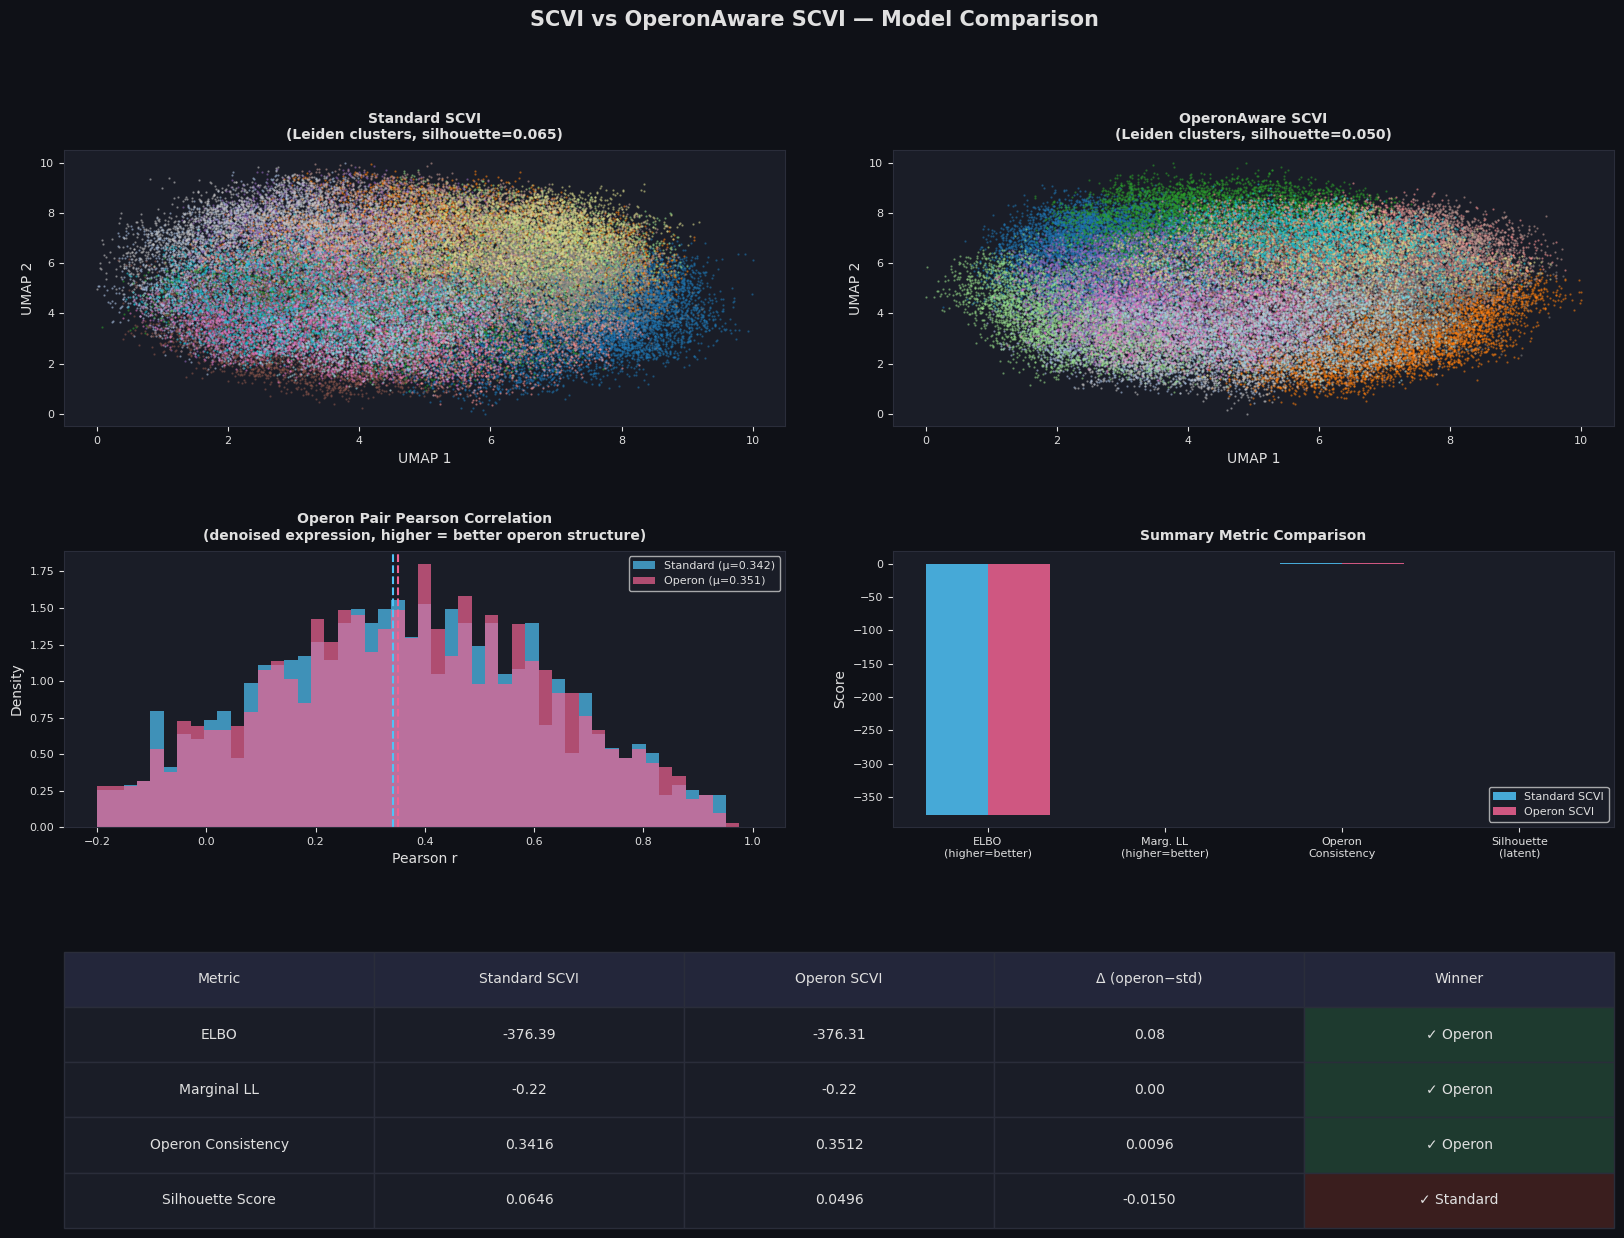

In [11]:
"""
compare_models.py
=================
Comprehensive comparison of standard SCVI vs OperonAwareSCVI for microbiome data.

Metrics covered:
  1. ELBO / reconstruction loss (held-out)
  2. Marginal log-likelihood
  3. Operon consistency score (key microbiome-specific metric)
  4. Latent space quality  - silhouette score, UMAP
  5. Training curve comparison
  6. Differential expression sanity check
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scanpy as sc
import scvi
import torch
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

from scvi.model import SCVI as StandardSCVI
from scvi.model import OperonAwareSCVI
from load_neighbor_indices import load_neighbor_indices

# ─────────────────────────────────────────────
# 0.  Load data + models
# ─────────────────────────────────────────────
print("Loading data and models...")
import scanpy as sc
adata = sc.read_h5ad("pountain_data/outputs/lb_adata.h5ad")
scvi.data.setup_anndata(adata)

neighbor_indices = load_neighbor_indices("operon_neighbors.csv", adata)

model_standard = StandardSCVI.load("pountain_data/outputs/lb_scVI_model_benchmark", adata=adata)
model_operon   = OperonAwareSCVI.load("pountain_data/outputs/lb_scVI_model_operon_aware", adata=adata)

print(f"  Cells: {adata.n_obs:,}  |  Genes: {adata.n_vars:,}")
print(f"  Operon pairs used: {neighbor_indices.shape[1]:,}")


# ─────────────────────────────────────────────
# 1.  ELBO (reconstruction + KL) on full data
# ─────────────────────────────────────────────
def get_elbo(model):
    """Returns mean ELBO over the dataset (higher = better)."""
    return model.get_elbo()

print("\n── 1. ELBO ──")
elbo_std    = get_elbo(model_standard)
elbo_operon = get_elbo(model_operon)
print(f"  Standard SCVI  ELBO: {elbo_std:.2f}")
print(f"  Operon SCVI    ELBO: {elbo_operon:.2f}")
print(f"  Δ (operon−std):      {elbo_operon - elbo_std:.2f}  {'✓ operon better' if elbo_operon > elbo_std else '✗ standard better'}")


# ─────────────────────────────────────────────
# 2.  Marginal log-likelihood (n_mc_samples=50)
# ─────────────────────────────────────────────
print("\n── 2. Marginal Log-Likelihood (50 MC samples) ──")
mll_std    = model_standard.get_marginal_ll(n_mc_samples=50)
mll_operon = model_operon.get_marginal_ll(n_mc_samples=50)
print(f"  Standard SCVI  MLL: {mll_std:.2f}")
print(f"  Operon SCVI    MLL: {mll_operon:.2f}")
print(f"  Δ (operon−std):     {mll_operon - mll_std:.2f}  {'✓ operon better' if mll_operon > mll_std else '✗ standard better'}")


# ─────────────────────────────────────────────
# 3.  Operon Consistency Score  ← key metric
#     Measures how similar normalized expression
#     is between operon-neighbor gene pairs.
#     Higher = model respects operon structure.
# ─────────────────────────────────────────────
print("\n── 3. Operon Consistency Score ──")

def operon_consistency(model, neighbor_indices, n_cells=2000):
    """
    For each operon neighbor pair (g1, g2), compute Pearson correlation
    of their normalized (denoised) expression across cells.
    Returns mean correlation over all pairs.
    """
    # Subsample cells for speed
    idx = np.random.choice(model.adata.n_obs, size=min(n_cells, model.adata.n_obs), replace=False)
    subset = model.adata[idx].copy()
    scvi.data.setup_anndata(subset)

    norm_expr = model.get_normalized_expression(adata=subset)  # (n_cells, n_genes)
    norm_expr = norm_expr.values  # numpy array

    g1 = neighbor_indices[0].numpy()
    g2 = neighbor_indices[1].numpy()

    correlations = []
    for i in range(len(g1)):
        r, _ = pearsonr(norm_expr[:, g1[i]], norm_expr[:, g2[i]])
        if not np.isnan(r):
            correlations.append(r)

    return np.mean(correlations), np.std(correlations), correlations

np.random.seed(42)
mean_std,  std_std,  corrs_std  = operon_consistency(model_standard, neighbor_indices)
mean_op,   std_op,   corrs_op   = operon_consistency(model_operon,   neighbor_indices)

print(f"  Standard SCVI  operon consistency: {mean_std:.4f} ± {std_std:.4f}")
print(f"  Operon SCVI    operon consistency: {mean_op:.4f} ± {std_op:.4f}")
print(f"  Δ (operon−std):                    {mean_op - mean_std:.4f}  {'✓ operon better' if mean_op > mean_std else '✗ standard better'}")


# ─────────────────────────────────────────────
# 4.  Latent space quality — silhouette score
#     Uses leiden clusters on each latent space.
# ─────────────────────────────────────────────
print("\n── 4. Latent Space Quality (Silhouette Score) ──")

def latent_silhouette(model, key_name):
    z = model.get_latent_representation()
    adata.obsm[key_name] = z
    sc.pp.neighbors(adata, use_rep=key_name, n_neighbors=15)
    sc.tl.leiden(adata, key_added=f"{key_name}_leiden", resolution=0.5)
    labels = LabelEncoder().fit_transform(adata.obs[f"{key_name}_leiden"])
    # Subsample for speed
    idx = np.random.choice(len(z), size=min(5000, len(z)), replace=False)
    score = silhouette_score(z[idx], labels[idx], metric="euclidean")
    return score, z

sil_std,  z_std  = latent_silhouette(model_standard, "X_scvi_std")
sil_op,   z_op   = latent_silhouette(model_operon,   "X_scvi_op")

print(f"  Standard SCVI  silhouette: {sil_std:.4f}")
print(f"  Operon SCVI    silhouette: {sil_op:.4f}")
print(f"  Δ (operon−std):            {sil_op - sil_std:.4f}  {'✓ operon better' if sil_op > sil_std else '✗ standard better'}")


# ─────────────────────────────────────────────
# 5.  Visualisation: UMAPs + metric summary
# ─────────────────────────────────────────────
print("\n── 5. Generating plots ──")

# Compute UMAPs
sc.tl.umap(adata, neighbors_key="neighbors")   # reuse last neighbor graph (operon)
adata.obsm["X_umap_op"]  = adata.obsm["X_umap"].copy()

sc.pp.neighbors(adata, use_rep="X_scvi_std", n_neighbors=15)
sc.tl.umap(adata)
adata.obsm["X_umap_std"] = adata.obsm["X_umap"].copy()

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor("#0f1117")
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

DARK  = "#0f1117"
PANEL = "#1a1d27"
ACC1  = "#4fc3f7"   # cyan  – standard
ACC2  = "#f06292"   # pink  – operon
TEXT  = "#e0e0e0"

def dark_ax(ax, title=""):
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_edgecolor("#2a2d3a")
    ax.tick_params(colors=TEXT, labelsize=8)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    if title:
        ax.set_title(title, color=TEXT, fontsize=10, fontweight="bold", pad=8)

# Row 0: UMAPs
ax_u1 = fig.add_subplot(gs[0, :2])
ax_u2 = fig.add_subplot(gs[0, 2:])

for ax, umap_key, cluster_key, color, label in [
    (ax_u1, "X_umap_std", "X_scvi_std_leiden", ACC1, "Standard SCVI"),
    (ax_u2, "X_umap_op",  "X_scvi_op_leiden",  ACC2, "OperonAware SCVI"),
]:
    coords = adata.obsm[umap_key]
    labels_u = adata.obs[cluster_key].astype("category")
    n_clusters = labels_u.nunique()
    cmap = plt.cm.get_cmap("tab20", n_clusters)
    for i, cl in enumerate(labels_u.cat.categories):
        mask = labels_u == cl
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   s=0.4, alpha=0.5, color=cmap(i), rasterized=True)
    dark_ax(ax, f"{label}\n(Leiden clusters, silhouette={sil_std if 'std' in cluster_key else sil_op:.3f})")
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")

# Row 1, col 0-1: Operon consistency distribution
ax_corr = fig.add_subplot(gs[1, :2])
bins = np.linspace(-0.2, 1.0, 50)
ax_corr.hist(corrs_std, bins=bins, alpha=0.7, color=ACC1, label=f"Standard (μ={mean_std:.3f})", density=True)
ax_corr.hist(corrs_op,  bins=bins, alpha=0.7, color=ACC2, label=f"Operon (μ={mean_op:.3f})",   density=True)
ax_corr.axvline(mean_std, color=ACC1, lw=1.5, ls="--")
ax_corr.axvline(mean_op,  color=ACC2, lw=1.5, ls="--")
dark_ax(ax_corr, "Operon Pair Pearson Correlation\n(denoised expression, higher = better operon structure)")
ax_corr.set_xlabel("Pearson r"); ax_corr.set_ylabel("Density")
ax_corr.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)

# Row 1, col 2-3: Bar chart summary
ax_bar = fig.add_subplot(gs[1, 2:])
metrics = {
    "ELBO\n(higher=better)":       (elbo_std,    elbo_operon),
    "Marg. LL\n(higher=better)":   (mll_std,     mll_operon),
    "Operon\nConsistency":         (mean_std,    mean_op),
    "Silhouette\n(latent)":        (sil_std,     sil_op),
}
x = np.arange(len(metrics))
w = 0.35
bars1 = ax_bar.bar(x - w/2, [v[0] for v in metrics.values()], w, color=ACC1, alpha=0.85, label="Standard SCVI")
bars2 = ax_bar.bar(x + w/2, [v[1] for v in metrics.values()], w, color=ACC2, alpha=0.85, label="Operon SCVI")
ax_bar.set_xticks(x); ax_bar.set_xticklabels(list(metrics.keys()), fontsize=7.5)
dark_ax(ax_bar, "Summary Metric Comparison")
ax_bar.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
ax_bar.set_ylabel("Score")

# Row 2: Numeric summary table
ax_tbl = fig.add_subplot(gs[2, :])
ax_tbl.axis("off")
dark_ax(ax_tbl)

def winner(a, b):
    return "✓ Operon" if b > a else ("✓ Standard" if a > b else "Tie")

table_data = [
    ["Metric", "Standard SCVI", "Operon SCVI", "Δ (operon−std)", "Winner"],
    ["ELBO",              f"{elbo_std:.2f}",   f"{elbo_operon:.2f}", f"{elbo_operon-elbo_std:.2f}",   winner(elbo_std, elbo_operon)],
    ["Marginal LL",       f"{mll_std:.2f}",    f"{mll_operon:.2f}",  f"{mll_operon-mll_std:.2f}",    winner(mll_std, mll_operon)],
    ["Operon Consistency",f"{mean_std:.4f}",   f"{mean_op:.4f}",     f"{mean_op-mean_std:.4f}",      winner(mean_std, mean_op)],
    ["Silhouette Score",  f"{sil_std:.4f}",    f"{sil_op:.4f}",      f"{sil_op-sil_std:.4f}",        winner(sil_std, sil_op)],
]
tbl = ax_tbl.table(
    cellText=table_data[1:], colLabels=table_data[0],
    cellLoc="center", loc="center",
    bbox=[0.0, 0.0, 1.0, 1.0]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor("#23263a" if r == 0 else PANEL)
    cell.set_edgecolor("#2a2d3a")
    cell.set_text_props(color=TEXT)
    if r > 0 and c == 4 and r <= len(table_data) - 1:  # winner column
        txt = table_data[r][4]   # r=1 → table_data[1], r=2 → table_data[2], etc.
        cell.set_facecolor("#1e3a2f" if "Operon" in txt else "#3a1e1e" if "Standard" in txt else PANEL)

fig.suptitle("SCVI vs OperonAware SCVI — Model Comparison",
             color=TEXT, fontsize=15, fontweight="bold", y=0.98)

plt.savefig("pountain_data/outputs/model_comparison.png",
            dpi=150, bbox_inches="tight", facecolor=DARK)
print("  Saved → pountain_data/outputs/model_comparison.png")

# ─────────────────────────────────────────────
# 6.  Print final verdict
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("VERDICT")
print("="*55)
scores = {
    "ELBO":               elbo_operon > elbo_std,
    "Marginal LL":        mll_operon  > mll_std,
    "Operon Consistency": mean_op     > mean_std,
    "Silhouette Score":   sil_op      > sil_std,
}
operon_wins = sum(scores.values())
for metric, operon_better in scores.items():
    print(f"  {'✓' if operon_better else '✗'} {metric}: {'Operon' if operon_better else 'Standard'} wins")
print(f"\n  Overall: Operon SCVI wins {operon_wins}/4 metrics")
if operon_wins >= 3:
    print("  → OperonAwareSCVI is the BETTER model for this dataset.")
elif operon_wins == 2:
    print("  → Mixed results — consider tuning lambda_val.")
else:
    print("  → Standard SCVI performs better — operon penalty may be too strong.")
print("="*55)

Loading data and models...
INFO     No batch_key inputted, assuming all cells are same batch                                                  
INFO     No label_key inputted, assuming all cells have same label                                                 
INFO     Using data from adata.X                                                                                   
INFO     Computing library size prior per batch                                                                    
INFO     Successfully registered anndata object containing 57627 cells, 3070 vars, 1 batches, 1 labels, and 0      
         proteins. Also registered 0 extra categorical covariates and 0 extra continuous covariates.               
INFO     Please do not further modify adata until model is trained.                                                
INFO     Using data from adata.X                                                                                   
INFO     Computing library size prior per bat

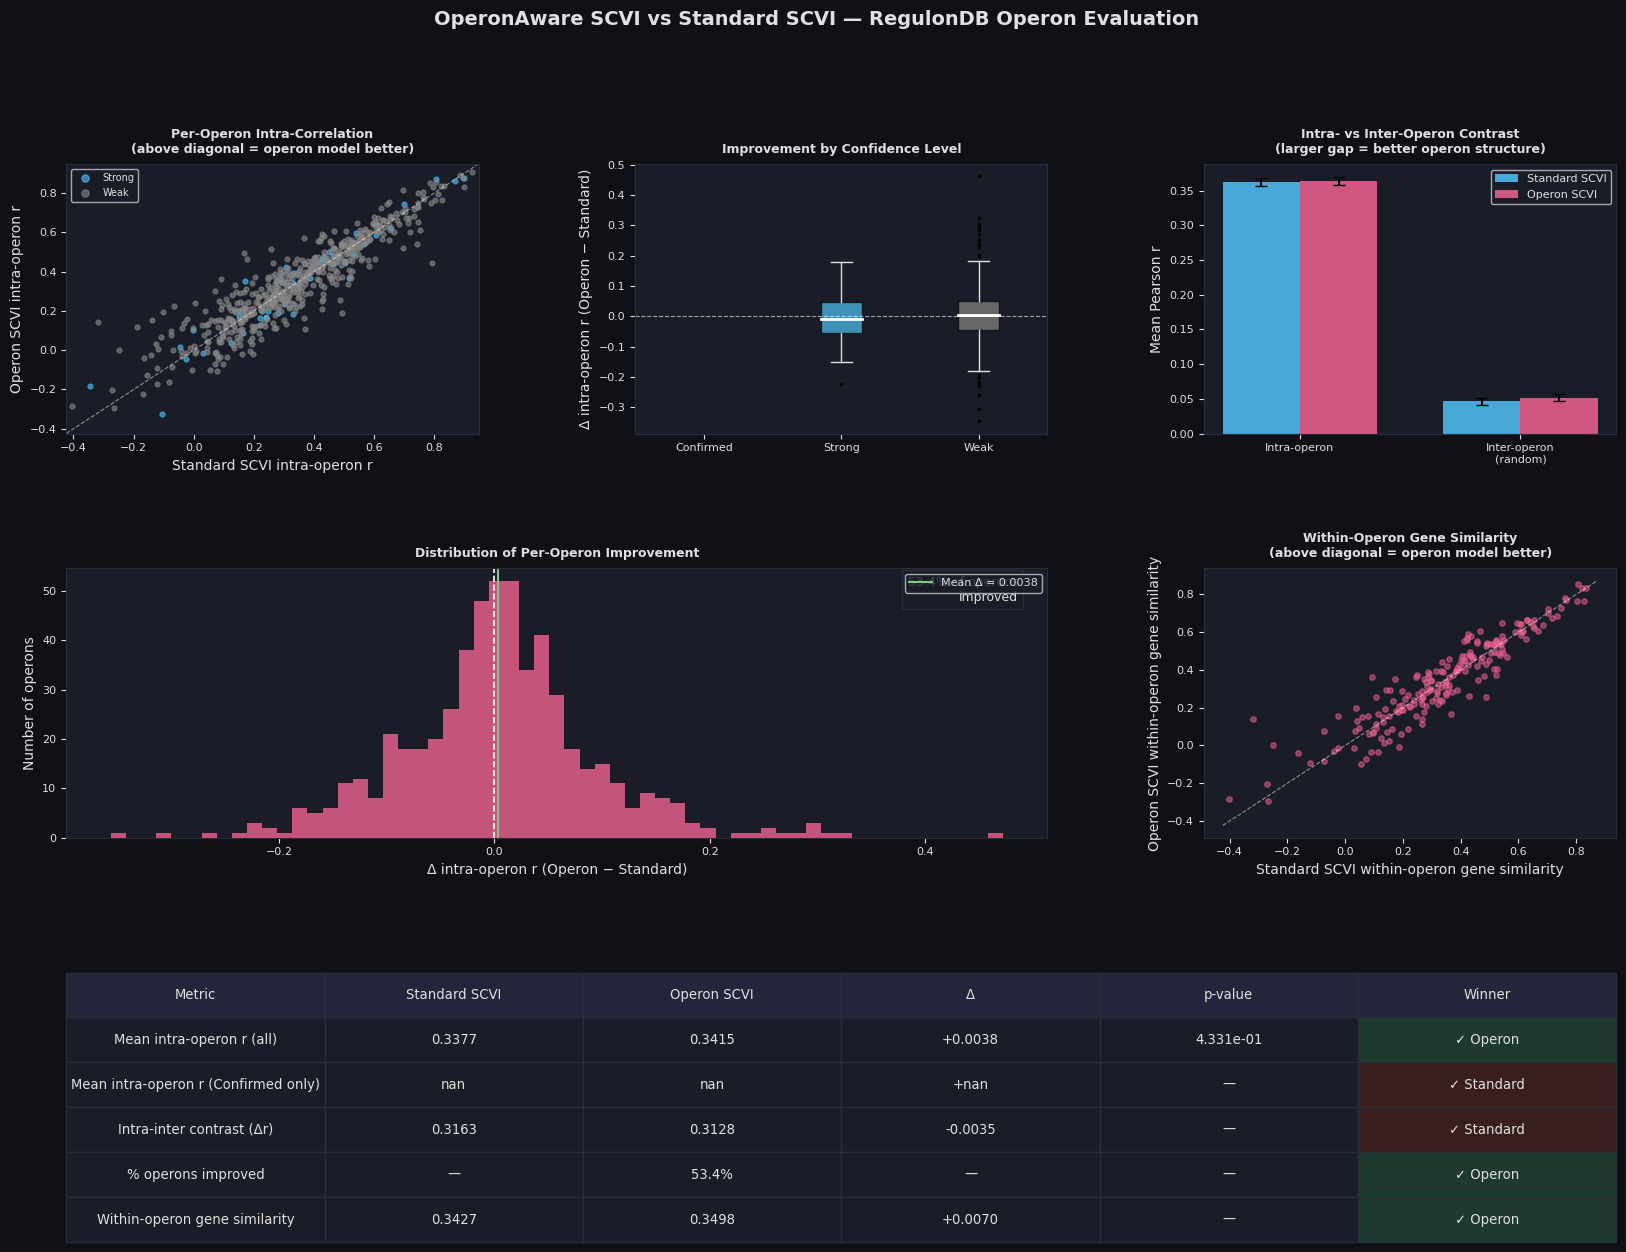

In [13]:
"""
evaluate_operons_regulondb.py
==============================
RegulonDB ground-truth operon evaluation of Standard SCVI vs OperonAwareSCVI.
Assumes you already ran compare_models.py for ELBO, MLL, silhouette, and UMAP.

Depends on:
    gene_mapping.py   — GFF parsing, symbol → adata index mapping
    operon_utils.py   — RegulonDB parsing and filtering

New metrics:
  1. Per-operon intra-operon correlation (stratified by confidence level)
  2. Intra- vs inter-operon contrast
  3. Within-operon gene similarity
  4. Top improved / degraded operons
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr, mannwhitneyu
from itertools import combinations
import scanpy as sc
import scvi
import warnings
warnings.filterwarnings("ignore")

from scvi.model import SCVI as StandardSCVI
from scvi.model import OperonAwareSCVI
from gene_mapping import build_gene_to_idx       # <-- utility 1
from operon_utils import load_operons            # <-- utility 2

# ── Paths — edit these ───────────────────────
ADATA_PATH    = "pountain_data/outputs/lb_adata.h5ad"
MODEL_STD     = "pountain_data/outputs/lb_scVI_model_benchmark"
MODEL_OPERON  = "pountain_data/outputs/lb_scVI_model_operon_aware"
GFF_PATH      = "pountain_data/reference/GCF_000005845.2_ASM584v2_genomic.gff"                      # your GFF file
OPERON_TSV    = "OperonSet.tsv"                  # RegulonDB operonset
OUT_PLOT      = "pountain_data/outputs/regulondb_operon_evaluation.png"
OUT_CSV       = "pountain_data/outputs/per_operon_results.csv"
N_CELLS       = 3000                             # cells to subsample for speed
# ─────────────────────────────────────────────

DARK  = "#0f1117"
PANEL = "#1a1d27"
ACC1  = "#4fc3f7"
ACC2  = "#f06292"
ACC3  = "#81c784"
TEXT  = "#e0e0e0"

def dark_ax(ax, title=""):
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_edgecolor("#2a2d3a")
    ax.tick_params(colors=TEXT, labelsize=8)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    if title:
        ax.set_title(title, color=TEXT, fontsize=9, fontweight="bold", pad=8)


# ═══════════════════════════════════════════
# 0.  Load data, models, mappings
# ═══════════════════════════════════════════
print("=" * 55)
print("Loading data and models...")
adata = sc.read_h5ad(ADATA_PATH)
scvi.data.setup_anndata(adata)

model_std = StandardSCVI.load(MODEL_STD,       adata=adata)
model_op  = OperonAwareSCVI.load(MODEL_OPERON, adata=adata)
print(f"  Cells: {adata.n_obs:,}  |  Genes: {adata.n_vars:,}")

print("\nBuilding gene name mapping from GFF...")
gene_to_idx = build_gene_to_idx(GFF_PATH, adata)

print("\nLoading RegulonDB operons...")
operons_valid = load_operons(OPERON_TSV, gene_to_idx)


# ═══════════════════════════════════════════
# 1.  Denoised expression (shared cell subset)
# ═══════════════════════════════════════════
print("\nComputing denoised expression...")
np.random.seed(42)
cell_idx  = np.random.choice(adata.n_obs, size=min(N_CELLS, adata.n_obs), replace=False)
adata_sub = adata[cell_idx].copy()
scvi.data.setup_anndata(adata_sub)

expr_std = model_std.get_normalized_expression(adata=adata_sub).values
expr_op  = model_op.get_normalized_expression(adata=adata_sub).values


# ═══════════════════════════════════════════
# 2.  Per-operon intra-operon correlation
# ═══════════════════════════════════════════
print("Computing per-operon intra-operon correlations...")

def safe_pearsonr(a, b):
    if np.std(a) < 1e-10 or np.std(b) < 1e-10:
        return np.nan
    return pearsonr(a, b)[0]

def mean_pairwise_corr(expr, gidx):
    rs = [safe_pearsonr(expr[:, i], expr[:, j])
          for i, j in combinations(gidx, 2)]
    rs = [r for r in rs if not np.isnan(r)]
    return np.mean(rs) if rs else np.nan

results = []
for _, row in operons_valid.iterrows():
    gidx = row["idx_found"]
    results.append({
        "operon_name": row["operon_name"],
        "n_genes":     len(gidx),
        "confidence":  row["confidence_label"],
        "r_standard":  mean_pairwise_corr(expr_std, gidx),
        "r_operon":    mean_pairwise_corr(expr_op,  gidx),
    })

res_df = pd.DataFrame(results)
print(f"  Raw: {len(res_df)} operons | "
      f"NaN r_standard: {res_df['r_standard'].isna().sum()} | "
      f"NaN r_operon: {res_df['r_operon'].isna().sum()}")
res_df = res_df.dropna()
res_df["delta"] = res_df["r_operon"] - res_df["r_standard"]

stat, pval = mannwhitneyu(res_df["r_operon"], res_df["r_standard"], alternative="greater")

print(f"\n  Overall intra-operon r  ({len(res_df)} operons):")
print(f"    Standard : {res_df['r_standard'].mean():.4f} ± {res_df['r_standard'].std():.4f}")
print(f"    Operon   : {res_df['r_operon'].mean():.4f} ± {res_df['r_operon'].std():.4f}")
print(f"    Δ        : {res_df['delta'].mean():+.4f}  (Mann-Whitney p={pval:.3e})")

print("\n  By confidence level:")
for conf in ["Confirmed", "Strong", "Weak"]:
    sub = res_df[res_df["confidence"] == conf]
    if len(sub):
        print(f"    [{conf:9s}] n={len(sub):4d} | "
              f"Std={sub['r_standard'].mean():.4f}  "
              f"Op={sub['r_operon'].mean():.4f}  "
              f"Δ={sub['delta'].mean():+.4f}")


# ═══════════════════════════════════════════
# 3.  Intra- vs inter-operon contrast
# ═══════════════════════════════════════════
print("\nComputing intra- vs inter-operon contrast...")

intra_pairs = [(i, j)
               for _, row in operons_valid.iterrows()
               for i, j in combinations(row["idx_found"], 2)]
intra_set = set(intra_pairs)

np.random.seed(0)
all_idx, inter_pairs = list(range(adata.n_vars)), []
while len(inter_pairs) < len(intra_pairs):
    i, j = np.random.choice(all_idx, 2, replace=False)
    if (i, j) not in intra_set and (j, i) not in intra_set:
        inter_pairs.append((i, j))

def batch_corr(expr, pairs):
    rs = [safe_pearsonr(expr[:, i], expr[:, j]) for i, j in pairs]
    return np.array([r for r in rs if not np.isnan(r)])

intra_std = batch_corr(expr_std, intra_pairs)
intra_op  = batch_corr(expr_op,  intra_pairs)
inter_std = batch_corr(expr_std, inter_pairs)
inter_op  = batch_corr(expr_op,  inter_pairs)

contrast_std = intra_std.mean() - inter_std.mean()
contrast_op  = intra_op.mean()  - inter_op.mean()

print(f"  Intra mean r  | Std={intra_std.mean():.4f}  Op={intra_op.mean():.4f}")
print(f"  Inter mean r  | Std={inter_std.mean():.4f}  Op={inter_op.mean():.4f}")
print(f"  Contrast Δr   | Std={contrast_std:.4f}  Op={contrast_op:.4f}  "
      f"({'✓ operon better' if contrast_op > contrast_std else '✗ standard better'})")


# ═══════════════════════════════════════════
# 4.  Within-operon gene similarity
# ═══════════════════════════════════════════
print("\nComputing within-operon gene similarity...")

prox_std, prox_op = [], []
for _, row in operons_valid.head(200).iterrows():
    gidx = row["idx_found"]
    for expr, store in [(expr_std, prox_std), (expr_op, prox_op)]:
        sub  = expr[:, gidx].T
        corr = np.corrcoef(sub)
        triu = np.triu_indices(len(gidx), k=1)
        store.append(corr[triu].mean())

print(f"  Std={np.mean(prox_std):.4f}  Op={np.mean(prox_op):.4f}  "
      f"({'✓ operon better' if np.mean(prox_op) > np.mean(prox_std) else '✗ standard better'})")


# ═══════════════════════════════════════════
# 5.  Top improved / degraded operons
# ═══════════════════════════════════════════
pct_improved = (res_df["delta"] > 0).mean() * 100
print(f"\n  {pct_improved:.1f}% of operons improved by operon-aware model\n")
print("Top 10 most improved:")
print(res_df.nlargest(10, "delta")[
    ["operon_name","n_genes","confidence","r_standard","r_operon","delta"]
].to_string(index=False))
print("\nTop 10 where standard was better:")
print(res_df.nsmallest(10, "delta")[
    ["operon_name","n_genes","confidence","r_standard","r_operon","delta"]
].to_string(index=False))


# ═══════════════════════════════════════════
# 6.  Plots
# ═══════════════════════════════════════════
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor(DARK)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)

# 6a. Scatter per-operon
ax1 = fig.add_subplot(gs[0, 0])
conf_colors = {"Confirmed": ACC3, "Strong": ACC1, "Weak": "#888"}
for conf, grp in res_df.groupby("confidence"):
    ax1.scatter(grp["r_standard"], grp["r_operon"],
                s=12, alpha=0.6, color=conf_colors.get(conf, "#888"),
                label=conf, rasterized=True)
lims = [min(res_df[["r_standard","r_operon"]].min())-0.02,
        max(res_df[["r_standard","r_operon"]].max())+0.02]
ax1.plot(lims, lims, "w--", lw=0.8, alpha=0.5)
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel("Standard SCVI intra-operon r")
ax1.set_ylabel("Operon SCVI intra-operon r")
ax1.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=7, markerscale=1.5)
dark_ax(ax1, "Per-Operon Intra-Correlation\n(above diagonal = operon model better)")

# 6b. Boxplot by confidence
ax2 = fig.add_subplot(gs[0, 1])
bp = ax2.boxplot([res_df[res_df["confidence"]==c]["delta"].values
                  for c in ["Confirmed","Strong","Weak"]],
                 patch_artist=True, notch=False,
                 medianprops=dict(color="white", lw=2),
                 whiskerprops=dict(color=TEXT), capprops=dict(color=TEXT),
                 flierprops=dict(marker=".", color="#555", markersize=3))
for patch, col in zip(bp["boxes"], [ACC3, ACC1, "#888"]):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax2.axhline(0, color="white", lw=0.8, ls="--", alpha=0.6)
ax2.set_xticklabels(["Confirmed", "Strong", "Weak"])
ax2.set_ylabel("Δ intra-operon r (Operon − Standard)")
dark_ax(ax2, "Improvement by Confidence Level")

# 6c. Intra vs inter contrast
ax3 = fig.add_subplot(gs[0, 2])
x, w = np.arange(2), 0.35
for offset, means, errs, col, label in [
    (-w/2, [intra_std.mean(), inter_std.mean()],
           [intra_std.std()/np.sqrt(len(intra_std)), inter_std.std()/np.sqrt(len(inter_std))],
           ACC1, "Standard SCVI"),
    (+w/2, [intra_op.mean(), inter_op.mean()],
           [intra_op.std()/np.sqrt(len(intra_op)), inter_op.std()/np.sqrt(len(inter_op))],
           ACC2, "Operon SCVI"),
]:
    ax3.bar(x+offset, means, w, color=col, alpha=0.85, label=label,
            yerr=errs, capsize=4, error_kw=dict(color=TEXT))
ax3.set_xticks(x); ax3.set_xticklabels(["Intra-operon", "Inter-operon\n(random)"])
ax3.set_ylabel("Mean Pearson r")
ax3.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
dark_ax(ax3, "Intra- vs Inter-Operon Contrast\n(larger gap = better operon structure)")

# 6d. Delta histogram
ax4 = fig.add_subplot(gs[1, :2])
bins = np.linspace(res_df["delta"].min()-0.01, res_df["delta"].max()+0.01, 60)
ax4.hist(res_df["delta"], bins=bins, color=ACC2, alpha=0.8, edgecolor="none")
ax4.axvline(0, color="white", lw=1.2, ls="--")
ax4.axvline(res_df["delta"].mean(), color=ACC3, lw=1.5,
            label=f"Mean Δ = {res_df['delta'].mean():.4f}")
ax4.text(0.97, 0.88, f"{pct_improved:.1f}% of operons\nimproved",
         transform=ax4.transAxes, ha="right", color=TEXT, fontsize=9,
         bbox=dict(facecolor=PANEL, edgecolor="#2a2d3a", pad=4))
ax4.set_xlabel("Δ intra-operon r (Operon − Standard)")
ax4.set_ylabel("Number of operons")
ax4.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
dark_ax(ax4, "Distribution of Per-Operon Improvement")

# 6e. Gene similarity scatter
ax5 = fig.add_subplot(gs[1, 2])
ax5.scatter(prox_std, prox_op, s=15, alpha=0.5, color=ACC2, rasterized=True)
lims2 = [min(min(prox_std),min(prox_op))-0.02, max(max(prox_std),max(prox_op))+0.02]
ax5.plot(lims2, lims2, "w--", lw=0.8, alpha=0.5)
ax5.set_xlabel("Standard SCVI within-operon gene similarity")
ax5.set_ylabel("Operon SCVI within-operon gene similarity")
dark_ax(ax5, "Within-Operon Gene Similarity\n(above diagonal = operon model better)")

# 6f. Summary table
ax6 = fig.add_subplot(gs[2, :])
ax6.axis("off"); dark_ax(ax6)

def winner(a, b): return "✓ Operon" if b > a else "✓ Standard"

conf_sub   = res_df[res_df.confidence == "Confirmed"]
table_data = [
    ["Metric", "Standard SCVI", "Operon SCVI", "Δ", "p-value", "Winner"],
    ["Mean intra-operon r (all)",
     f"{res_df['r_standard'].mean():.4f}", f"{res_df['r_operon'].mean():.4f}",
     f"{res_df['delta'].mean():+.4f}", f"{pval:.3e}",
     winner(res_df['r_standard'].mean(), res_df['r_operon'].mean())],
    ["Mean intra-operon r (Confirmed only)",
     f"{conf_sub['r_standard'].mean():.4f}", f"{conf_sub['r_operon'].mean():.4f}",
     f"{conf_sub['delta'].mean():+.4f}", "—",
     winner(conf_sub['r_standard'].mean(), conf_sub['r_operon'].mean())],
    ["Intra-inter contrast (Δr)",
     f"{contrast_std:.4f}", f"{contrast_op:.4f}",
     f"{contrast_op-contrast_std:+.4f}", "—", winner(contrast_std, contrast_op)],
    ["% operons improved", "—", f"{pct_improved:.1f}%", "—", "—",
     "✓ Operon" if pct_improved > 50 else "✓ Standard"],
    ["Within-operon gene similarity",
     f"{np.mean(prox_std):.4f}", f"{np.mean(prox_op):.4f}",
     f"{np.mean(prox_op)-np.mean(prox_std):+.4f}", "—",
     winner(np.mean(prox_std), np.mean(prox_op))],
]

tbl = ax6.table(cellText=table_data[1:], colLabels=table_data[0],
                cellLoc="center", loc="center", bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(9.5)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor("#23263a" if r == 0 else PANEL)
    cell.set_edgecolor("#2a2d3a")
    cell.set_text_props(color=TEXT)
    if r > 0 and c == 5 and r <= len(table_data)-1:
        cell.set_facecolor("#1e3a2f" if "Operon" in table_data[r][5] else "#3a1e1e")

fig.suptitle("OperonAware SCVI vs Standard SCVI — RegulonDB Operon Evaluation",
             color=TEXT, fontsize=14, fontweight="bold", y=0.99)
plt.savefig(OUT_PLOT, dpi=150, bbox_inches="tight", facecolor=DARK)
print(f"\nSaved → {OUT_PLOT}")

res_df.to_csv(OUT_CSV, index=False)
print(f"Saved → {OUT_CSV}")

# ═══════════════════════════════════════════
# 7.  Verdict
# ═══════════════════════════════════════════
print("\n" + "="*55)
wins = {
    "Intra-operon correlation":      res_df["delta"].mean() > 0,
    "Intra-inter contrast":          contrast_op > contrast_std,
    "% operons improved (>50%)":     pct_improved > 50,
    "Within-operon gene similarity": np.mean(prox_op) > np.mean(prox_std),
}
for metric, operon_wins in wins.items():
    print(f"  {'✓' if operon_wins else '✗'} {metric}: {'Operon' if operon_wins else 'Standard'} wins")
print(f"\n  Operon SCVI wins {sum(wins.values())}/{len(wins)} RegulonDB metrics")
print("="*55)

In [15]:
print(list(adata.var_names[:10]))
print(operons_valid["genes_found"])

['b0002', 'b0003', 'b0004', 'b0005', 'b0006', 'b0007', 'b0008', 'b0009', 'b0010', 'b0014']
0                        [ycaR, kdsB]
1                        [yjjU, yjjV]
2                  [yqcC, truC, yqcA]
3                        [dinJ, yafQ]
4                        [pgpC, tadA]
                    ...              
555                [glnA, glnL, glnG]
556    [serV, argV, argY, argZ, argQ]
557                       [acs, actP]
558                      [pntA, pntB]
559    [gatY, gatZ, gatA, gatB, gatD]
Name: genes_found, Length: 560, dtype: object


In [17]:
from operon_utils import parse_regulondb_operons

operons_df = parse_regulondb_operons("OperonSet.tsv")
operons_df["genes_found"] = operons_df["genes"].apply(
    lambda gl: [g for g in gl if g in gene_to_idx])
operons_df["n_found"] = operons_df["genes_found"].apply(len)

# Now check Confirmed operons
confirmed = operons_df[operons_df["confidence_label"] == "Confirmed"]
print(f"Total Confirmed operons: {len(confirmed)}")
print(confirmed["n_found"].value_counts())
print(confirmed[confirmed["n_found"] >= 2][["operon_name","genes","genes_found"]].head(10))

[operon_utils] Parsed 848 multi-gene operons from RegulonDB
Weak      787
Strong     61
Total Confirmed operons: 0
Series([], Name: n_found, dtype: int64)
Empty DataFrame
Columns: [operon_name, genes, genes_found]
Index: []


In [19]:
# Check what confidence codes actually exist in the raw file
with open("OperonSet.tsv") as f:
    for line in f:
        if line.startswith("#") or line.startswith("1)"):
            continue
        parts = line.strip().split("\t")
        if len(parts) > 8 and parts[8].strip() == "C":
            print(line)
            break
# Will print nothing — C simply doesn't exist in this release

In [20]:
strong = res_df[res_df["confidence"] == "Strong"]
print(f"Strong operons evaluated: {len(strong)}")
print(f"  Standard SCVI : {strong['r_standard'].mean():.4f} ± {strong['r_standard'].std():.4f}")
print(f"  Operon SCVI   : {strong['r_operon'].mean():.4f} ± {strong['r_operon'].std():.4f}")
print(f"  Δ             : {strong['delta'].mean():+.4f}")
print(f"  % improved    : {(strong['delta'] > 0).mean()*100:.1f}%")

# Also see which specific Strong operons improved most
print("\nTop 10 Strong operons by improvement:")
print(strong.nlargest(10, "delta")[
    ["operon_name","n_genes","r_standard","r_operon","delta"]
].to_string(index=False))

Strong operons evaluated: 46
  Standard SCVI : 0.3395 ± 0.2494
  Operon SCVI   : 0.3341 ± 0.2574
  Δ             : -0.0054
  % improved    : 45.7%

Top 10 Strong operons by improvement:
   operon_name  n_genes  r_standard  r_operon    delta
         mcrBC        2    0.171888  0.350277 0.178389
       idnDOTR        2   -0.345346 -0.181892 0.163453
     amiA-hemF        2    0.306995  0.423888 0.116893
       edd-eda        2   -0.001376  0.104139 0.105515
         carAB        2    0.276720  0.353584 0.076864
         cydDC        2    0.286831  0.362648 0.075817
         metBL        2    0.330032  0.392974 0.062942
      ackA-pta        2    0.805651  0.868449 0.062799
         cusRS        2   -0.046205  0.015156 0.061361
hemA-prfA-prmC        3    0.539484  0.595066 0.055582


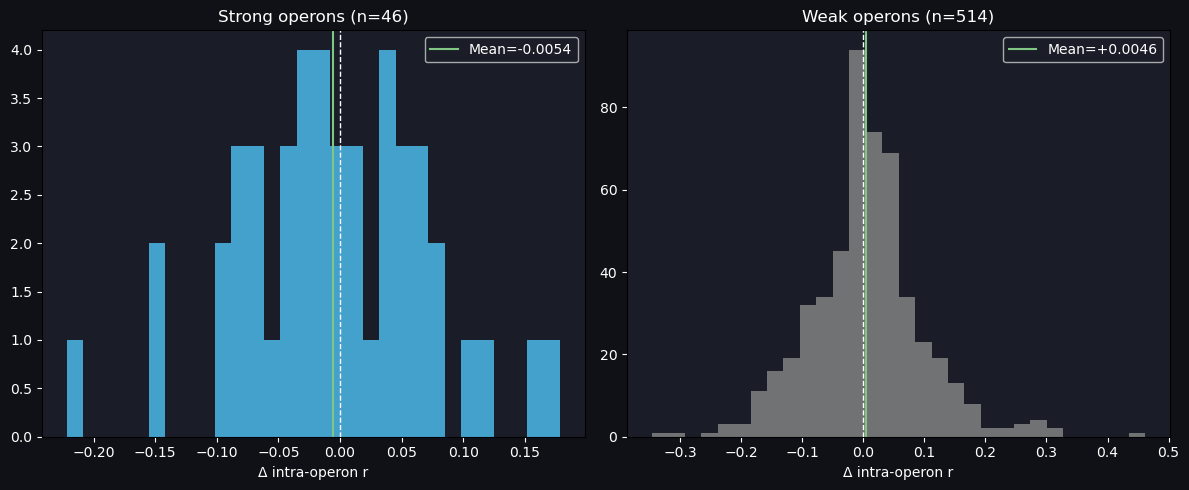

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor="#0f1117")
for ax, conf, col in zip(axes, ["Strong", "Weak"], ["#4fc3f7", "#888"]):
    sub = res_df[res_df["confidence"] == conf]
    ax.hist(sub["delta"], bins=30, color=col, alpha=0.8, edgecolor="none")
    ax.axvline(0, color="white", lw=1, ls="--")
    ax.axvline(sub["delta"].mean(), color="#81c784", lw=1.5,
               label=f"Mean={sub['delta'].mean():+.4f}")
    ax.set_facecolor("#1a1d27")
    ax.set_title(f"{conf} operons (n={len(sub)})", color="white")
    ax.set_xlabel("Δ intra-operon r", color="white")
    ax.tick_params(colors="white")
    ax.legend(facecolor="#1a1d27", labelcolor="white")
plt.tight_layout()
plt.savefig("pountain_data/outputs/strong_vs_weak_operons.png",
            dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()